# Experiment 10: Data Visualization III

Use the dataset from DS_lab10 (IRIS.csv), scan the dataset, and infer feature behavior with histograms and boxplots.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style='whitegrid', context='notebook')

# Load IRIS.csv from DS_lab10 and make schema robust
file_path = 'IRIS.csv'
expected_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

raw = pd.read_csv(file_path, header=None)
first_row = [str(x).strip().lower() for x in raw.iloc[0].tolist()]

# If header row exists inside data, drop it
if first_row == expected_cols:
    raw = raw.iloc[1:].reset_index(drop=True)

raw.columns = expected_cols

# Enforce numeric feature types for plotting
for col in expected_cols[:-1]:
    raw[col] = pd.to_numeric(raw[col], errors='coerce')

df = raw.dropna(subset=expected_cols[:-1]).copy()

print('Dataset shape:', df.shape)
df.head()

Dataset shape: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [2]:
# 1) List features and their types (numeric / nominal)
feature_types = []
for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        ftype = 'Numeric'
    else:
        ftype = 'Nominal'
    feature_types.append((col, str(df[col].dtype), ftype))

feature_df = pd.DataFrame(feature_types, columns=['Feature', 'Pandas_DType', 'Type'])
feature_df

,Feature,Pandas_DType,Type
0,sepal_length,float64,Numeric
1,sepal_width,float64,Numeric
2,petal_length,float64,Numeric
3,petal_width,float64,Numeric
4,species,object,Nominal


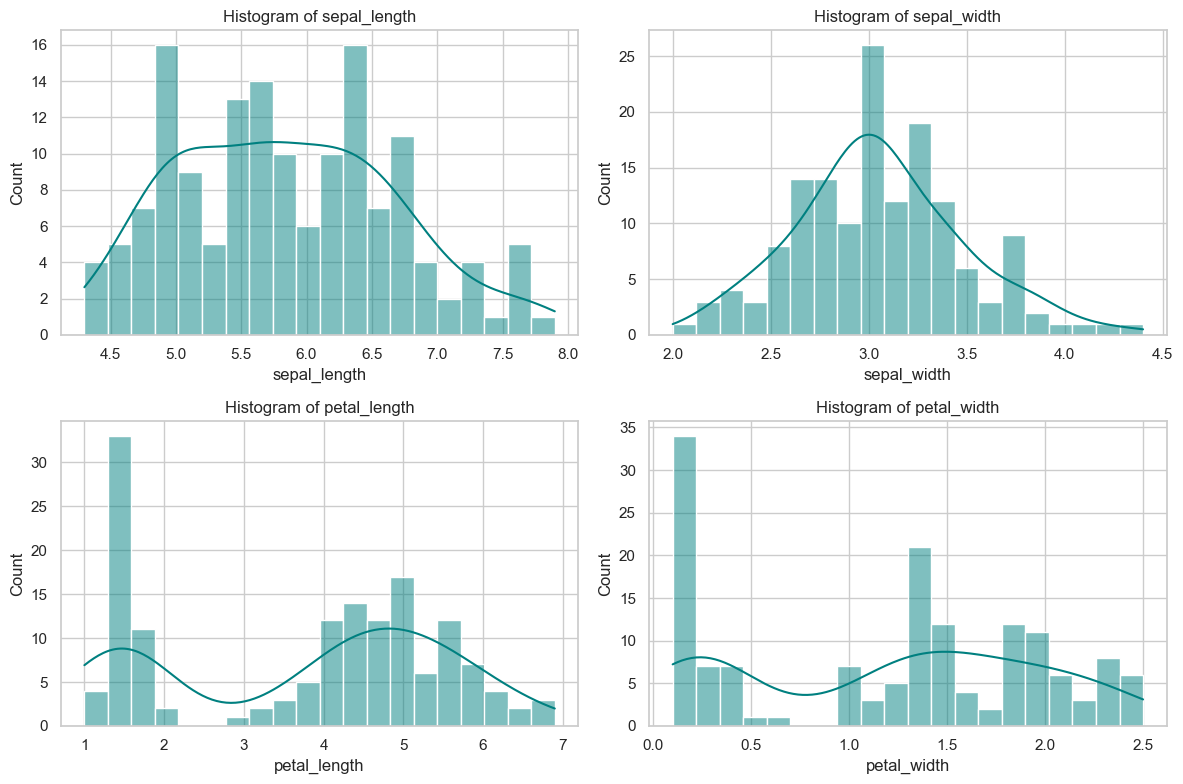

In [3]:
# 2) Histogram for each numeric feature
numeric_cols = df.select_dtypes(include='number').columns

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax, bins=20, color='teal')
    ax.set_title(f'Histogram of {col}')

plt.tight_layout()
plt.show()

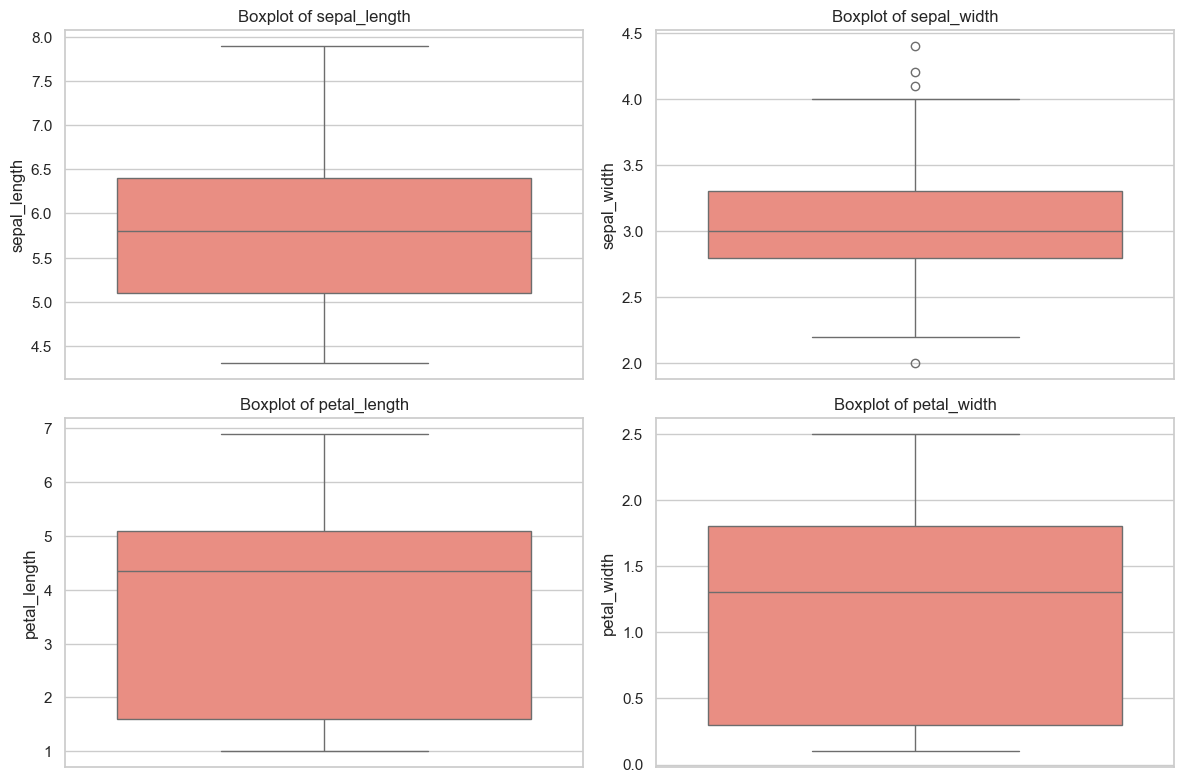

In [4]:
# 3) Boxplot for each numeric feature
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df[col], ax=ax, color='salmon')
    ax.set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

In [5]:
# 4) Compare distributions and identify outliers using IQR rule
outlier_report = []
for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = df[(df[col] < lower) | (df[col] > upper)][col]
    outlier_report.append({
        'feature': col,
        'Q1': round(q1, 3),
        'Q3': round(q3, 3),
        'IQR': round(iqr, 3),
        'Lower_Bound': round(lower, 3),
        'Upper_Bound': round(upper, 3),
        'Outlier_Count': int(outliers.count())
    })

outlier_df = pd.DataFrame(outlier_report)
outlier_df

,feature,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count
0,sepal_length,5.1,6.4,1.3,3.15,8.35,0
1,sepal_width,2.8,3.3,0.5,2.05,4.05,4
2,petal_length,1.6,5.1,3.5,-3.65,10.35,0
3,petal_width,0.3,1.8,1.5,-1.95,4.05,0


## Inference

1. Numeric features: sepal_length, sepal_width, petal_length, petal_width. Nominal feature: species.
2. Histograms usually show petal features are more distinctly grouped than sepal features, indicating stronger class separation.
3. Boxplots indicate spread differences: petal_length and petal_width often exhibit clearer distribution shifts compared to sepal features.
4. The IQR-based outlier table highlights which features contain atypical values; these points can be reviewed before modeling.
5. Overall, petal measurements are generally more informative for distinguishing iris classes.